## 1. Imports

In [77]:
import matplotlib.pyplot as plt
import numpy as np
import time

# from multiprocessing.dummy import Pool as ThreadPool
from concurrent.futures import ProcessPoolExecutor

## 2. Timeseries Data Simulation

### Simulate BDM

$$
dX_t = k  (\mu - X_t) dt + D \sqrt{X_t} dW_t
$$

Update rule : $X_{t + dt} = X_t + k(\mu - X_t)dt + D \sqrt{X_t} \eta$

In [78]:
def BDM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * (mu - X[i-1]) * dt + np.sqrt(X[i-1]) * dW[i-1]

    return X[-1]

In [79]:
def BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = BDM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

### Simulate SLM

$$
dX_t = k  X_t (\mu - X_t) dt + D X_t dW_t
$$

Update rule : $ X_{t + dt} = X_t + k X_t ( \mu - X_t) dt + D X_t \eta $

In [80]:
def SLM_step(X0, k, mu, D, dt, timestepsperpoint):
    t = np.linspace(0, timestepsperpoint - 1, timestepsperpoint)
    X = np.zeros(timestepsperpoint)
    X[0] = X0

    dW = D * np.random.normal(size=timestepsperpoint)

    #Euler-Maruyama iteration
    for i in range(1,timestepsperpoint):
        X[i] = X[i-1] + k * X[i-1] * (mu - X[i-1]) * dt + X[i-1] * dW[i-1]

    return X[-1]

In [81]:
def SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N):
    datapoints = np.zeros(N)
    datapoints[0] = X0

    for idx in range(1,N):
        datapoints[idx] = SLM_step(datapoints[idx-1], k, mu, D, dt, timestepsperpoint)

    return datapoints

### Wrapper Function

In [82]:
def simulate_timeseries(model='BDM', params=None):
    
    valid_models = {"BDM", "SLM"}
    X0, k, mu, D, dt, timestepsperpoint, N = params

    if params == None:
        raise ValueError("No parameters passed to simulate_timeseries()!")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        sim_data = BDM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)
    elif model == 'SLM':
        sim_data = SLM_simulate_ts(X0, k, mu, D, dt, timestepsperpoint, N)

    return sim_data

### Simulation Parameters

In [83]:
MODEL = 'SLM'

In [84]:
X0 = 4.5
k = 3
mu = 5
D = 0.005

dt = 3e-3 #timestep of the simulation

T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
N = round(T+1 / eff_dt) #number of datapoints

timestepsperpoint = round(eff_dt / dt)

### Run simulation and visualize

In [85]:
sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))

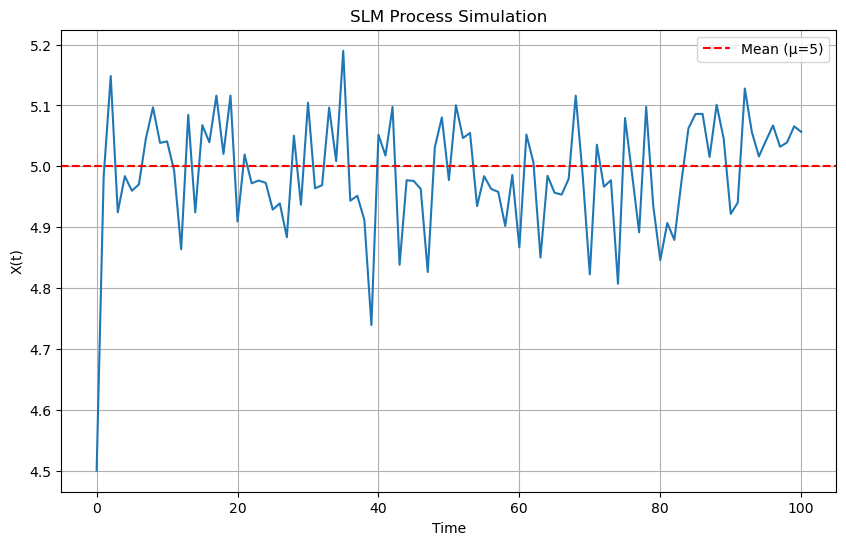

In [86]:
# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

## 3. Lamperti transform of timeseries data

In [87]:
def BDM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Square root is not defined for negative numbers.")    
    result = 2 * np.sqrt(arr)
    return result
    
def SLM_Lamperti(ts_data):
    arr = np.array(ts_data)      
    # Check for negative values
    if np.any(arr < 0):
        raise ValueError("Input array contains negative values. Log is not defined for negative numbers.")    
    result = np.log(arr)
    return result

## 4. Generating Wiener Bridges

In [88]:
# Parameters
NB = 10000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

datapoint_times = np.linspace(0, T, N)

In [105]:
def bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D):        
    B = np.empty((NB, bridge_steps), dtype=np.float32) #to store simulated X values for bridges
    B[:, 0] = x_i
    B[:, -1] = x_f     
    for step in range(1, bridge_steps - 1): 
        #ATTENTION: Manal's script had (bridge_steps - step) * B[:, step - 1] + x_f with a PLUS!! Is this a grave typo in Javier's?
        mean_b = ((bridge_steps - step) * B[:, step - 1] + x_f ) / (bridge_steps - step + 1)        
        var_b = (D**2 * (bridge_steps - step) * Delta_t_B ) / (bridge_steps - step + 1)      
        B[:, step] = np.random.randn(NB) * np.sqrt(var_b) + mean_b    
    return B

## 5. Getting $\hat{I}$ from a bridge

In [90]:
#This is not necessary, but useful to keep.

def A_BDM(k, mu, x):
    return (2 * k * mu - 0.5 * k * x**2 - 0.5) / x

def A_SLM(k, mu, x):
    return k * (mu - np.exp(x) - 0.5)

In [91]:
def I_hat(k, mu, B, Delta_t_B, model='BDM'):
    
    valid_models = {"BDM", "SLM"}

    B = np.array(B)

    if B.ndim != 1:
        raise ValueError(f"Expected 1D array, but got {B.ndim}D array with shape {B.shape}")
    
    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        Ihat = np.sum(((2 * k * mu - 0.5 * k * B**2 - 0.5) / B)**2) * Delta_t_B
    elif model == 'SLM':
        Ihat = np.sum((k * (mu - np.exp(B)) - 0.5)**2) * Delta_t_B

    return Ihat

## 6. Calculating Radon-Nikodym Derivative from Bridge Values

In [92]:
def RN_Derivative_BDM(B, k, mu, D, Delta_t_B):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='BDM')

    return np.exp(  
        (( 2 * k * mu * np.log(x_f/x_i) - 
          np.log(x_f/x_i) * 0.5 - 
          k * (x_f**2 - x_i**2) * 0.25 )/
        (D**2)) -
        (Ihat / ( 2 * (D**2) ) )
    )

def RN_Derivative_SLM(B, k, mu, D, Delta_t_B):
    x_i = B[0]
    x_f = B[-1]

    Ihat = I_hat(k, mu, B, Delta_t_B, model='SLM')

    return np.exp(
        ((
            (k * mu - 0.5)*(x_f - x_i) - 
            k*(np.exp(x_f) - np.exp(x_i))
        ) / (D**2)) - 
        ( Ihat / (2 * (D**2)) )
    )

In [93]:
def RN_Derivative(B, k, mu, D, Delta_t_B, model='BDM'):
    valid_models = {"BDM", "SLM"}

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        return RN_Derivative_BDM(B, k, mu, D, Delta_t_B)
    elif model == 'SLM':
        return RN_Derivative_SLM(B, k, mu, D, Delta_t_B)

## 7. Estimating the propagator $\hat{\rho}_{s,t}(\tilde{x}|\tilde{y}) = \sum_{i=1}^{N_B} L_t^{(i)} / N_B$

In [94]:
def RND_each_bridge(bridges, k, mu, D, Delta_t_B, model='BDM'):

    #Array of L_t for each bridge
    L_array = np.array([])

    #For each bridge, calculate L and append to array
    for bridge in bridges:
        L_array = np.append(L_array, RN_Derivative(bridge, k, mu, D, Delta_t_B, model))

    return L_array

In [95]:
def est_propagator(bridges, k, mu, D, Delta_t_B, model='BDM'):
    L_array = RND_each_bridge(bridges, k, mu, D, Delta_t_B, model)
    return np.average(L_array)

## 8. Compute propagators of transformed data

In [96]:
def propagators_transformed_data(data, NB, bridge_steps, Delta_t_B, D, k, mu, model='BDM'):
    
    rho_array = np.array([])

    successive_datapoints = np.column_stack((data[:-1], data[1:]))

    for x_i, x_f in successive_datapoints:
        bridges = bridge(NB, bridge_steps, x_i, x_f, Delta_t_B, D)
        propagator = est_propagator(bridges, k, mu, D, Delta_t_B, model)
        rho_array = np.append(rho_array, propagator)

    return rho_array

## 9. Propagator of target process (inverting change of variable)

In [97]:
def propagators_target_process(rho_array, data, model='BDM'):
    valid_models = {"BDM", "SLM"}

    data = data[1:]

    if model not in valid_models:
        raise ValueError(f"Invalid model: {model}. Must be one of: {', '.join(valid_models)}")
    elif model == 'BDM':
        h_prime = 1 / np.sqrt(data)
        return h_prime * rho_array
    elif model == 'SLM':
        h_prime = 1 / data
        return h_prime * rho_array

## 10. Log likelihood of timeseries

In [98]:
def ts_logL(rho_array, p0):
    return np.sum(np.log(rho_array)) + np.log(p0)

## 11. Testing: Simulate a timeseries and use the bridge method to calculate the likelihood that the data was produced b a given model

In [100]:
# Parameters
NB = 10000  # Number of bridges per transition
timestep_ratio = 1e3 # dt / Dt

bridge_steps = int(eff_dt * timestep_ratio) # Number of time steps inside bridge
Delta_t_B = eff_dt / bridge_steps 

datapoint_times = np.linspace(0, T, N)

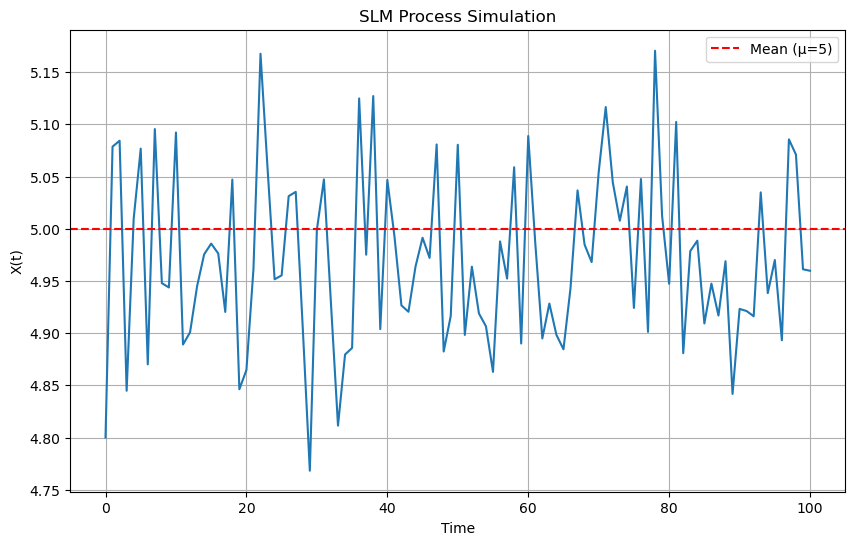

In [101]:
MODEL = 'SLM'

X0 = 4.8
k = 3
mu = 5
D = 0.005

dt = 3e-3 #timestep of the simulation

T = 100 #timeseries timespan, starts at 0 and ends at T
eff_dt = 1 #timestep of the datapoints
N = round(T+1 / eff_dt) #number of datapoints

timestepsperpoint = round(eff_dt / dt)

sim_data = simulate_timeseries(model=MODEL, params=(X0, k, mu, D, dt, timestepsperpoint, N))

# Plot result
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, sim_data)
plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [102]:
lamperti_tf_data = SLM_Lamperti(sim_data)

/tmp/ipykernel_37467/421333305.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


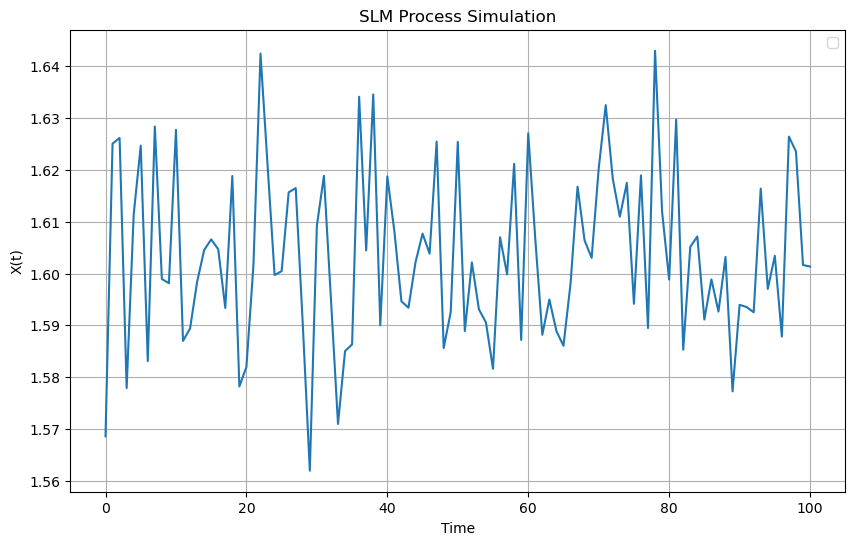

In [104]:
plt.figure(figsize=(10, 6))
timepoints = np.linspace(0, T, N)
plt.plot(timepoints, lamperti_tf_data)
# plt.axhline(y=mu, color='r', linestyle='--', label=f'Mean (μ={mu})')
plt.xlabel('Time')
plt.ylabel('X(t)')
plt.title(f'{MODEL} Process Simulation')
plt.legend()
plt.grid(True)
plt.show()

In [106]:
rho_tilde_array = propagators_transformed_data(lamperti_tf_data, NB, bridge_steps, Delta_t_B, D, k, mu, model=MODEL)

In [107]:
print(rho_tilde_array)

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 2.81846663e-14
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 4.24503009e-36 2.10637244e-25 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.25832398e-44 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.000000

In [108]:
timeseries_logL = ts_logL(propagators_target_process(rho_tilde_array, sim_data, 'SLM'), 1.0)

/tmp/ipykernel_37467/1109162141.py:2: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(rho_array)) + np.log(p0)


In [109]:
timeseries_logL

np.float64(-inf)